In [3]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append('../src')
import pandas as pd
from pre_processing import df_transform_experimental, prepare_for_training
from training import run_cv_training, run_training
from analysis import *
from custom_scoring import calculate_macro_ap
import os
os.environ["WANDB_SILENT"] = "true"
import wandb

DATA_PATH = '../data/train.csv'
CLASS_NAMES = ["Clutter", "Cormorants", "Pigeons", "Ducks", "Geese", "Gulls", "Birds of Prey", "Waders", "Songbirds"]

params = {
            'n_estimators': 1000,
            'learning_rate': 0.05,
            'max_depth': 6,
            'objective': 'multi:softprob',
            'num_class': len(CLASS_NAMES),
            'tree_method': 'hist',
            'early_stopping_rounds': 50,
            'random_state': 42,
            'use_weights':True,
        }
features_config = {
    'airspeed': True,
    'min_z': True,
    'max_z': True,
    'size_Small bird': True,
    'size_Large bird': True,
    'size_Flock': True,
    'size_Medium bird': True,
    'size_encoding':'one_hot',
    'duration': True,
    'avg_rcs': True,
    'std_rcs': True,
    'min_rcs': True,
    'max_rcs': True,
    'height_fluctuation': True,
    'latitude_fluctuation': True,
    'longitude_fluctuation': True,
    'local_2d_circularity_max': True,
    'local_3d_circularity_mean': True
}
transform_config = {}

df = pd.read_csv(DATA_PATH)
transformed = df_transform_experimental(df, features_config, True)
X, y, features = prepare_for_training(transformed, features_config)

config = {
    'params':params,
    'feature_version':features,
}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
wandb.init(project="AICup", config=config)
models, oof_preds= run_cv_training(X, y, class_names=CLASS_NAMES, params=params)
final_score, detailed_scores = calculate_macro_ap(y, oof_preds, CLASS_NAMES)
wandb.log({"mean_macro_ap": final_score})
wandb.log({"detailed_scores": detailed_scores})
wandb.finish()

print(final_score)
debug_per_class_scores(y, oof_preds)

Fold 1 | Best Iter: 296 | Score: 0.9419
Fold 2 | Best Iter: 287 | Score: 0.8820
Fold 3 | Best Iter: 247 | Score: 0.8275
Fold 4 | Best Iter: 257 | Score: 0.8273
Fold 5 | Best Iter: 186 | Score: 0.8808
0.5438939680079713

--- Per-Class Performance ---


,Class,AP_Score,Support
5,Gulls,0.909076,1503
0,Clutter,0.820944,84
8,Songbirds,0.653652,483
2,Pigeons,0.583701,122
4,Geese,0.509085,83
6,Birds of Prey,0.478699,108
7,Waders,0.362561,120
3,Ducks,0.338502,58
1,Cormorants,0.238826,40


In [5]:
from kaggle_prediction import generate_ensemble_submission, generate_submission

#model = run_training(X, y, CLASS_NAMES, params=params)
#generate_submission(model, features_config)
generate_ensemble_submission(models, features_config)

Generating predictions for model 1/5...
Generating predictions for model 2/5...
Generating predictions for model 3/5...
Generating predictions for model 4/5...
Generating predictions for model 5/5...
Ensemble submission saved to: ../submissions/submission.csv


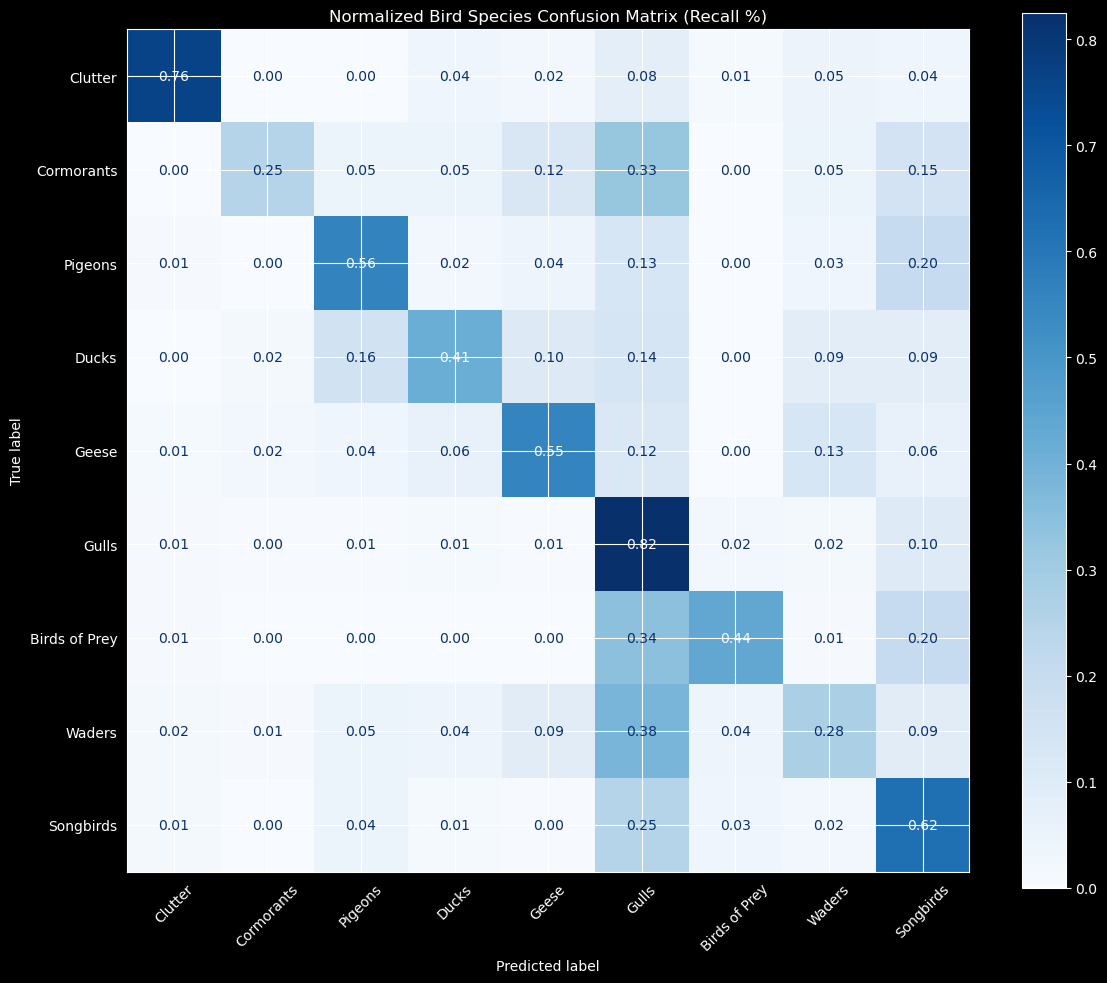

In [6]:
plot_bird_confusion(y ,oof_preds)

# Grid Search

In [7]:
sweep_config = {
    'method': 'grid', 
    'metric': {'name': 'mean_macro_ap', 'goal': 'maximize'},
    'parameters': {
        'learning_rate': {'values': [0.03, 0.05, 0.1]},
        'max_depth': {'values': [4, 6, 8]},
        'n_estimators': {'values': [1000]},
        'use_weights': {'values': [True, False]}
    }
}

sweep_id = wandb.sweep(sweep_config, project="AICup")

def sweep_train():
    with wandb.init() as run:
        current_params = wandb.config
        models, oof_preds = run_cv_training(
            X, y, 
            class_names=CLASS_NAMES, 
            params=current_params
        )

        final_score, detailed_scores = calculate_macro_ap(y, oof_preds, CLASS_NAMES)

        wandb.log({
            "mean_macro_ap": final_score,
            "detailed_scores": detailed_scores
        })

#wandb.agent(sweep_id, function=sweep_train)

Create sweep with ID: k7y42vdp
Sweep URL: https://wandb.ai/kubson-pieczonka-tu-delft/AICup/sweeps/k7y42vdp
Fold 1 | Best Iter: 619 | Score: 0.9637
Fold 2 | Best Iter: 798 | Score: 0.8677
Fold 3 | Best Iter: 806 | Score: 0.8319
Fold 4 | Best Iter: 717 | Score: 0.8745
Fold 5 | Best Iter: 587 | Score: 0.9372
Fold 1 | Best Iter: 269 | Score: 0.8552
Fold 2 | Best Iter: 339 | Score: 0.8205
Fold 3 | Best Iter: 320 | Score: 0.7926
Fold 4 | Best Iter: 303 | Score: 0.7940
Fold 5 | Best Iter: 230 | Score: 0.8543
Fold 1 | Best Iter: 472 | Score: 0.9345
Fold 2 | Best Iter: 540 | Score: 0.8788
Fold 3 | Best Iter: 497 | Score: 0.8222
Fold 4 | Best Iter: 385 | Score: 0.8437
Fold 5 | Best Iter: 354 | Score: 0.8732
Fold 1 | Best Iter: 163 | Score: 0.8691
Fold 2 | Best Iter: 245 | Score: 0.8446
Fold 3 | Best Iter: 257 | Score: 0.7877
Fold 4 | Best Iter: 233 | Score: 0.8239
Fold 5 | Best Iter: 178 | Score: 0.8827
Fold 1 | Best Iter: 289 | Score: 0.9400
Fold 2 | Best Iter: 353 | Score: 0.8829
Fold 3 | Best